# Missing values

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the data from a csv file
url = 'https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16A/data/pulsar_data_train.csv'
df = pd.read_csv(url)
df

# usually, missing values are Nan, np.Nan, and blank in the dataframe.

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
...,...,...,...,...,...,...,...,...,...
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


#### check missing values: there many methods to check missing values.

I notice that there are 12528 rows. 

In [3]:
df.info()

# 10793 < 12528, which means that there are missing values in the third column (column with index 2)
# similarly, we observe missing values in columns 5 and 7, where 5 and 7 are indices.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12528 entries, 0 to 12527
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                12528 non-null  float64
 1    Standard deviation of the integrated profile  12528 non-null  float64
 2    Excess kurtosis of the integrated profile     10793 non-null  float64
 3    Skewness of the integrated profile            12528 non-null  float64
 4    Mean of the DM-SNR curve                      12528 non-null  float64
 5    Standard deviation of the DM-SNR curve        11350 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           12528 non-null  float64
 7    Skewness of the DM-SNR curve                  11903 non-null  float64
 8   target_class                                   12528 non-null  float64
dtypes: float64(9)
memory usage: 881.0 KB


In [4]:
df.describe()

# the first row is the count of non-empty values.

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,12528.000000,12528.000000,10793.000000,12528.000000,12528.000000,11350.000000,12528.000000,11903.000000,12528.000000
mean,111.041841,46.521437,0.478548,1.778431,12.674758,26.351318,8.333489,105.525779,0.092034
std,25.672828,6.801077,1.064708,6.208450,29.613230,19.610842,4.535783,107.399585,0.289085
min,5.812500,24.772042,-1.738021,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.871094,42.362222,0.024652,-0.188142,1.910535,14.404353,5.803063,35.199899,0.000000
50%,115.183594,46.931022,0.223678,0.203317,2.792642,18.412402,8.451097,83.126301,0.000000
75%,127.109375,50.979103,0.473125,0.932374,5.413253,28.337418,10.727927,139.997850,0.000000
max,189.734375,91.808628,8.069522,68.101622,222.421405,110.642211,34.539844,1191.000837,1.000000


In [6]:
df.isnull().sum()

 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64

#### Dealing with missing values

Strategies:
1. Dropping missing values. Drop columns and drop rows. 

- Drop rows: it is used if we have large amount of samples. 
- Drop columns: it can be used if this column is not important. 

2. Fill-in missing values.
Suppose that we can not drop rows or columns, we want to fill in the missing values before we run some algorithms. 
This step is required because (usually) algorithms do not accept empty values. 

In [7]:
# dropna methond drops the rows with missing values. 
df.dropna()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
7,109.406250,55.912521,0.565106,0.056247,2.797659,19.496527,9.443282,97.374578,0.0
...,...,...,...,...,...,...,...,...,...
12522,124.828125,50.586731,0.233563,-0.286908,2.342809,13.949966,9.226188,117.308146,0.0
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


#### Fill in missing values:

When we fill in the misisng values, the general question is which number I should use.

1. Use some random numbers. Not so good because the numbers are not in the range.
2. Use mean, median, max, min, ...
3. Do some high-level analysis first (group level analysis), then use some statsitical quantities. 

In [9]:
# column 2: fill misisng values using 0
df.iloc[:,2].fillna(0)   # this is an out-of-place operation

# column 5: fill missing values using 10
df.iloc[:,5].fillna(10)

# column 7: fil; missing values using -10
df.iloc[:,7].fillna(-10)


0         65.159298
1        102.722975
2         74.031324
3          7.197842
4         76.291128
            ...    
12523     21.725143
12524     34.357283
12525    312.204325
12526     62.334018
12527    329.548016
Name:  Skewness of the DM-SNR curve, Length: 12528, dtype: float64

In [10]:
# use column mean:
df.iloc[:,2].fillna(df.iloc[:,2].mean())

0        0.375485
1        0.712898
2        0.133408
3       -0.215989
4        0.825013
           ...   
12523   -0.012418
12524    0.218177
12525    0.663456
12526   -0.089940
12527    0.346178
Name:  Excess kurtosis of the integrated profile, Length: 12528, dtype: float64

In [11]:
# use group mean: it is better to use group mean rather than 
# population average because of different numbers for different groups

df.groupby('target_class').mean()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve
target_class,,,,,,,,
0.0,116.568016,47.313376,0.209956,0.380851,8.900132,23.241487,8.896352,114.363754
1.0,56.522990,38.708515,3.123432,15.566358,49.913590,56.921437,2.780529,17.939904


In [13]:
# not in the final, but it is used in practice.
df.iloc[:,2].fillna(  df.groupby('target_class')[' Excess kurtosis of the integrated profile'].transform('mean') )

0        0.375485
1        0.712898
2        0.133408
3       -0.215989
4        0.825013
           ...   
12523   -0.012418
12524    0.218177
12525    0.663456
12526   -0.089940
12527    0.346178
Name:  Excess kurtosis of the integrated profile, Length: 12528, dtype: float64

# An example of Exploratory Data Analysis (EDA)

EDA is the process of analyzing and summarizing patterns of data using statistical quantities and data visualization.

This is a large topic and I am not able to cover everything. 

In our lecture, I use `Numpy`, `Pandas`, and `Matplotlib` to show an example of EDA. 

My focus is coding and I will touch some a little reasoning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read Dataset

In [2]:
url = "https://raw.githubusercontent.com/liaochunyang/PIC16/refs/heads/main/PIC16A/data/insurance.csv"
df = pd.read_csv(url)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


This dataset has 1338 samples and seven features where there are three categorical fatures: sex, smoker region and four numeric features: age, bmi, children, and charges. 

In [3]:
# check basic information
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Since we have categorical features, we have to do group level analysis
df.groupby('sex').size()
# we have similar amount of samples in each group, so it is balanced

sex
female    662
male      676
dtype: int64

In [6]:
df.groupby('smoker').size()
# feature smoker is imbalanced. 

smoker
no     1064
yes     274
dtype: int64

In [7]:
# check the average values of each group
df.groupby('smoker').mean()

# smoker is an important feature when we predict charges because the average charges of two groups are different.

,age,bmi,children,charges
smoker,,,,
no,39.385338,30.651795,1.090226,8434.268298
yes,38.514599,30.708449,1.113139,32050.231832


In [8]:
# 
df.groupby(['sex','region']).size()

sex     region   
female  northeast    161
        northwest    164
        southeast    175
        southwest    162
male    northeast    163
        northwest    161
        southeast    189
        southwest    163
dtype: int64

In [9]:
df1 = df.drop(columns=['smoker'])
df1.groupby(['sex','region']).size()

sex     region   
female  northeast    161
        northwest    164
        southeast    175
        southwest    162
male    northeast    163
        northwest    161
        southeast    189
        southwest    163
dtype: int64

In [10]:
df2 = df.drop(columns=['sex','region'])
df2.groupby(['smoker']).size()

smoker
no     1064
yes     274
dtype: int64

Comment: We have to try all combinations when we have a new dataset because we do not where is the correct direction.

In [11]:
# People prefer to use functions to simplify your code, reduce the code repition
def check_size(df, category):
    """
    Args:
    df: a pandas dataframe.
    category: a list of categorical features in df.
    """
    for i in category:
        print(df.groupby(i).size())
        print(" ")
        
category = ['sex', 'smoker', 'region']
check_size(df, category)


def check_size(df, category, numeric):
    
    # create a new df with category + numeric
    
    # do groupby
    pass

sex
female    662
male      676
dtype: int64
 
smoker
no     1064
yes     274
dtype: int64
 
region
northeast    324
northwest    325
southeast    364
southwest    325
dtype: int64
 


#### Correlation

- Positive (+1): there is strong positive linear relation between two features, e.g. weight and height, when height increases, then weight increases as well.

- Negative (-1): negative linear relation.

- Zero: There is no linear relation between two features.

In [12]:
df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation')

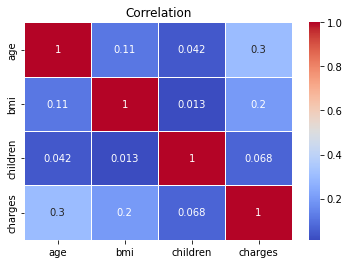

In [13]:
# heatmap
import seaborn as sns

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation')

# we cannot use matplotlib to do heatmap. Matplotlab is the building block. 
# seaborn is a new library based on matplotlib
# seaborn is helpful 

In [14]:
# Since we have categorical data, we are interested in the correlation of each group
df[ df['smoker'] == 'yes' ].corr()

# In the smoker group, I observe a strong linear relation between bmi and charges.
# In prediction, I should construct a model to combine smoker and bmi. 

,age,bmi,children,charges
age,1.000000,0.059674,0.081183,0.368224
bmi,0.059674,1.000000,-0.012619,0.806481
children,0.081183,-0.012619,1.000000,0.035945
charges,0.368224,0.806481,0.035945,1.000000


In [15]:
df[ df['smoker'] == 'no' ].corr()

# conclusion: for non-smoker group, bmi is not a key factor in determining the charges, but age is important.

,age,bmi,children,charges
age,1.000000,0.122638,0.033395,0.627947
bmi,0.122638,1.000000,0.019208,0.084037
children,0.033395,0.019208,1.000000,0.138929
charges,0.627947,0.084037,0.138929,1.000000


#### Histogram

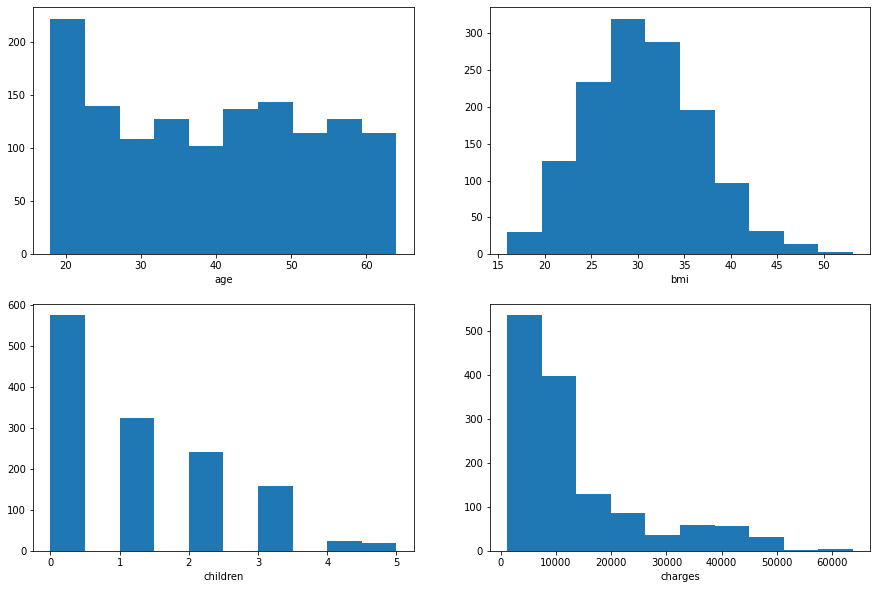

In [16]:
numeric = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(15,10))

for i in range(len(numeric)):
    
    plt.subplot(2,2,i+1)
    plt.hist(df[numeric[i]])
    plt.xlabel(numeric[i])
    
plt.show()

# age: uniform distribution
# bmi: normal distribution
# charges: exponential distribution

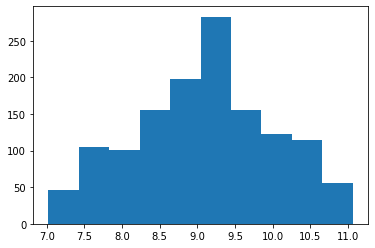

In [17]:
# can we do some transformation to get normal distribution? log, x, \sqrt(x)

plt.hist( df['charges'].apply(lambda x: np.log(x)) )
plt.show()
# After log transformation, I obtain a normal distribution.

# Next step: visualize the histograms for each group. 

# Scatter Plot

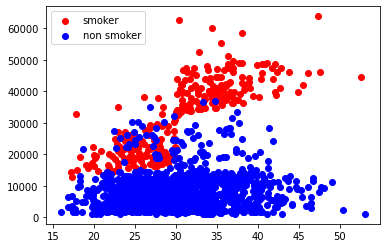

In [25]:
## Observation: in smoker group, bmi and charges have a strong linear relation

# smoker group and non-smoker group
df_smoker = df[ df['smoker']=='yes' ]
df_non = df[ df['smoker']=='no' ]

# visualization
plt.scatter(df_smoker['bmi'], df_smoker['charges'], label='smoker', c='red')
plt.scatter(df_non['bmi'], df_non['charges'], label='non smoker', c='blue')
plt.legend()

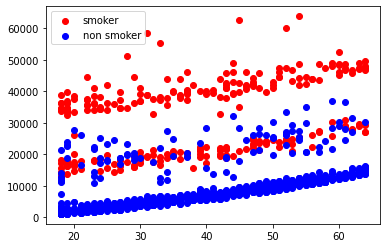

In [26]:
# Observation: for non-smoker group, age is the key factor 

# visualization
plt.scatter(df_smoker['age'], df_smoker['charges'], label='smoker', c='red')
plt.scatter(df_non['age'], df_non['charges'], label='non smoker', c='blue')
plt.legend()

# We also oberseve a linear relation here and a stratification phenomenon.
# It means that there is another factor affecting the charges.
# Unfortunately, I cannot find it.
# Maybe it is because this factor is not in the dataset.

# Encoding

Encoding string (categorical features) to numbers (numerical features).

- **Label Encoding**: each feature/category is represented by an integer. 

- **One-hot Encoding**: It works by creating a new binary column for each unique category. 

In [29]:
from sklearn.preprocessing import LabelEncoder

df_copy = df.copy()

# label encoder:
label_encoder = LabelEncoder()
df_copy['region'] = label_encoder.fit_transform(df_copy['region'])
df_copy

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,3,16884.92400
1,18,male,33.770,1,no,2,1725.55230
2,28,male,33.000,3,no,2,4449.46200
3,33,male,22.705,0,no,1,21984.47061
4,32,male,28.880,0,no,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,1,10600.54830
1334,18,female,31.920,0,no,0,2205.98080
1335,18,female,36.850,0,no,2,1629.83350
1336,21,female,25.800,0,no,3,2007.94500


In [30]:
# one-hot encoding
pd.get_dummies(df['region'], drop_first=False)

,northeast,northwest,southeast,southwest
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,1,0,0
4,0,1,0,0
...,...,...,...,...
1333,0,1,0,0
1334,1,0,0,0
1335,0,0,1,0
1336,0,0,0,1


In [ ]:
# Question: How can you write them as two functions?
# Goal: do encoding for all categorical features.

# Leave as an exercise, will be available in the final version.

# Transformation:

1. Obtain the target distribution.

2. We do not want to have large numbers in the data, e.g. numpy image has integer [0,1,...,255], here we can map [0,1,...,255] to [0,1].

3. We want to make all features be in the same scale.

4. ....

In [33]:
# select numeric features
numeric = ['age', 'bmi', 'children', 'charges']
df_numeric = df[numeric]

# Change it to a numpy array
X = df_numeric.to_numpy()
X

# transformation: statistics and broadcasting
# For each column, I want to minus the mean, and then divide by standard deviation
(X - np.mean(X, axis=0)) / np.std(X, axis=0)


## Normalization (minus mean and then divide by standard deviation): suppose that each feature follows a normal distribution,
# then normalization transforms it to a normal distribution with mean 0 and std 1.

## Standarization: map any data to a given range [a,b]. It is used if the data do not have distribution assumption.

array([[-1.43876426, -0.45332   , -0.90861367,  0.2985838 ],
       [-1.50996545,  0.5096211 , -0.07876719, -0.95368917],
       [-0.79795355,  0.38330685,  1.58092576, -0.72867467],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367, -0.96159623],
       [-1.29636188, -0.79781341, -0.90861367, -0.93036151],
       [ 1.55168573, -0.26138796, -0.90861367,  1.31105347]])

# Final: 70 pts. 

Cumulative: final is very similar to midterm 1 & 2. 

Cheet sheet: one side, handwritten (NO IPAD), A4. 

Time and Location: Dec 8 11:30-2:30pm lecture room.

- 1) True and False (30) 2) Read the code and write the output (11) 3) write the code (short can be done in 1-2 lines) (11)

Numpy:
1. axis=0 and axis=1
2. Broadcasting
3. Masking
4. random: np.random.uniform, np.random.normal, np.random.choice.
5. image processing. 
6. numpy array: shape, size, reshape. 


Pandas:
1. read and export csv
2. check columns, drop columns, rename columns
3. selection.
4. `df.apply`
5. label encoding vs one-hot encoding
6. deal with missing values (drop, fill-in na)
7. groupby
8. We have some methods df.describe(), df.info(), df.head(), df.tail()


Matplotlib:
1. plt.scatter, plt.plot, plt.hist
Sample question:
Given the following code
```python
x = np.random.normal(0,1,size=(1000,))
y = 5 * x + 10 + np.random.uniform(-1,1,size=(1000,))
plt.scatter(x,y)
```
The output is a line plot. (False)

Line plot is connecting points. 